In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CLEANED data (not the raw merge) — this is our EDA input
reviews = pd.read_parquet("../data/processed/master_clean.parquet")

# A fixed list of app names in a consistent order, so every chart
# shows the apps in the same left-to-right order.
apps = sorted(reviews["app_name"].unique())

print("Loaded:", reviews.shape)
print("Apps:", apps)

Loaded: (495967, 9)
Apps: ['chatgpt', 'facebook', 'netflix', 'snapchat', 'tiktok']


Counts: app_name
chatgpt     99884
facebook    98844
netflix     99206
snapchat    98960
tiktok      99073
Name: count, dtype: int64


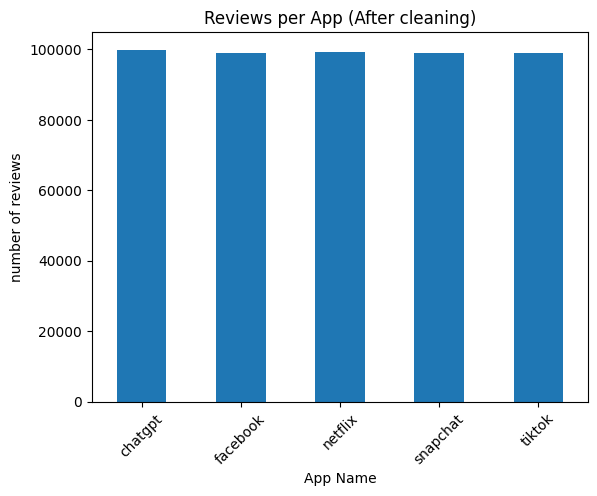

In [3]:
counts = reviews["app_name"].value_counts().sort_index()
print("Counts:", counts)

counts.plot(kind = "bar", title ="Reviews per App (After cleaning)")
plt.ylabel("number of reviews")
plt.xlabel("App Name")
plt.xticks(rotation=45)

plt.show()

Score Counts: score
1    112235
2     28449
3     34884
4     47151
5    273248
Name: count, dtype: int64


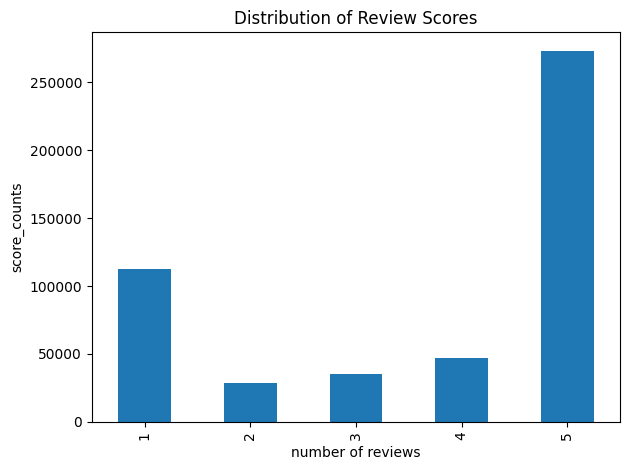

In [4]:
score_counts = reviews['score'].value_counts().sort_index()
print("Score Counts:", score_counts)

score_counts.plot(kind = "bar", title = "Distribution of Review Scores")
plt.ylabel("score_counts")
plt.xlabel("number of reviews")
plt.tight_layout()
plt.show()

In [5]:
app_score_counts = reviews.groupby('score')['app_name'].value_counts().unstack().fillna(0)
print("App Score Counts:\n", app_score_counts)

App Score Counts:
 app_name  chatgpt  facebook  netflix  snapchat  tiktok
score                                                 
1            6647     19243    38937     25689   21719
2            1916      4559     8473      7570    5931
3            4312      5505     9256      9245    6566
4           10457      7550    10708     10848    7588
5           76552     61987    31832     45608   57269


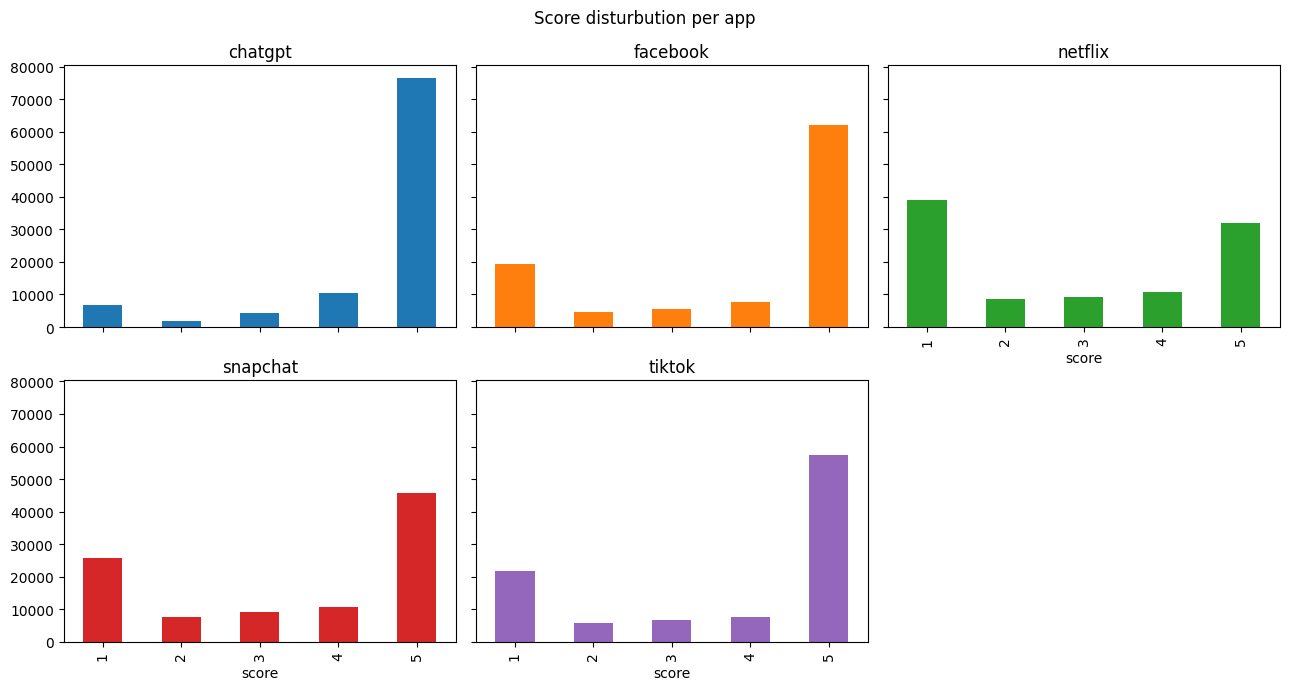

In [6]:
# .T flips the table so SCORE is on the x-axis and each APP becomes its own panel
axes = app_score_counts.plot(kind = "bar", subplots = True, layout = (2,3),  figsize = (13,7), legend = False, sharey = True, title = "Score disturbution per app")
plt.tight_layout()
plt.show()

In [9]:
reviews["char_len"] = reviews["content"].str.len()
print(reviews["char_len"].sum())
reviews["word_len"] = reviews["content"].str.split().str.len()
print(reviews[["word_len"]].sum())

print(reviews[["char_len", "word_len"]].describe())


40371156
word_len    7680677
dtype: int64
            char_len       word_len
count  495967.000000  495967.000000
mean       81.398875      15.486266
std       108.789072      20.442165
min         1.000000       1.000000
25%         9.000000       2.000000
50%        30.000000       6.000000
75%       118.000000      22.000000
max      1752.000000     331.000000


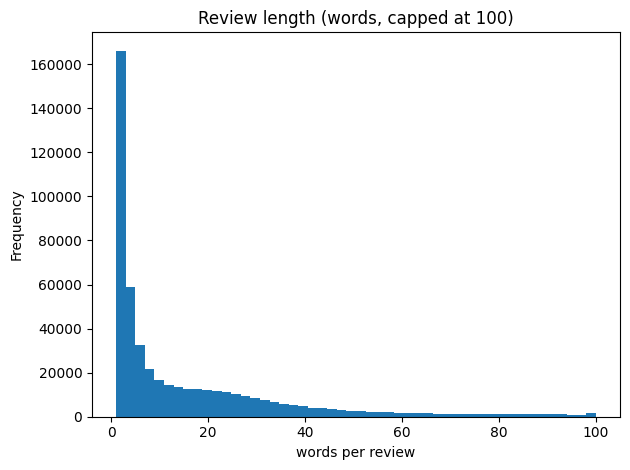

In [10]:
# Histogram of word counts. We cap the x-axis at 100 words because a
# long tail of rare huge reviews would otherwise squash everything.
reviews["word_len"].clip(upper=100).plot(
    kind="hist", bins=50, title="Review length (words, capped at 100)"
)
plt.xlabel("words per review")
plt.tight_layout()
plt.show()

In [11]:
# The embedding/clustering stage will EXCLUDE reviews with content length < 10.
# How many rows is that, and what share of each app?
short = reviews["char_len"] < 10

print("Total reviews under 10 chars:", short.sum())
print("Share of all reviews:", round(short.mean() * 100, 1), "%")
print("\nBy app:")
print(reviews.groupby("app_name")["char_len"].apply(lambda s: (s < 10).mean() * 100).round(1))

Total reviews under 10 chars: 139060
Share of all reviews: 28.0 %

By app:
app_name
chatgpt     41.4
facebook    45.7
netflix      6.2
snapchat    21.3
tiktok      25.6
Name: char_len, dtype: float64


In [12]:
# Right now `at` looks like "2026-07-23 08:08:54" but pandas treats it as plain text.
# Convert it to a real datetime so we can group by month, sort, etc.
reviews["at"] = pd.to_datetime(reviews["at"], format="mixed")

# Confirm the conversion worked and see the time span we're working with
print("dtype now:", reviews["at"].dtype)
print("earliest review:", reviews["at"].min())
print("latest review:", reviews["at"].max())

dtype now: datetime64[ns]
earliest review: 2018-09-12 07:22:12
latest review: 2026-07-23 08:08:54


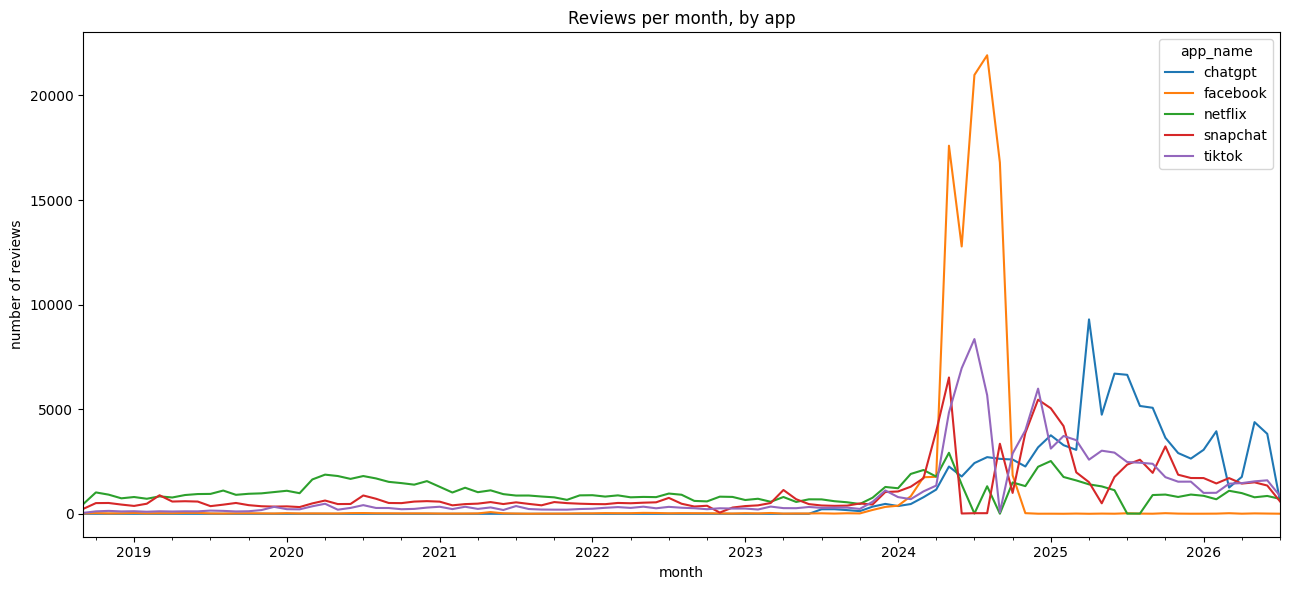

In [13]:
# Make a "year-month" label for each review, e.g. 2026-07
reviews["month"] = reviews["at"].dt.to_period("M")

# Count reviews per month for each app, then reshape into

# one line per app (months across the x-axis)
monthly = reviews.groupby(["month", "app_name"]).size().unstack(fill_value=0)

# Period index -> timestamps so matplotlib can plot it as a time axis
monthly.index = monthly.index.to_timestamp()

monthly.plot(figsize=(13, 6), title="Reviews per month, by app")
plt.ylabel("number of reviews")
plt.tight_layout()
plt.show()

In [14]:
# What fraction of reviews fall in the last 90 days of the dataset?
latest = reviews["at"].max()
recent_cutoff = latest - pd.Timedelta(days=90)

recent = reviews["at"] >= recent_cutoff
print("Latest review:", latest.date())
print("Reviews in last 90 days:", recent.sum(), f"({recent.mean()*100:.1f}%)")
print("\nBy app (% of that app's reviews in last 90 days):")
print(reviews.groupby("app_name")["at"].apply(lambda s: (s >= recent_cutoff).mean()*100).round(1))

Latest review: 2026-07-23
Reviews in last 90 days: 19455 (3.9%)

By app (% of that app's reviews in last 90 days):
app_name
chatgpt     8.9
facebook    0.0
netflix     2.5
snapchat    3.8
tiktok      4.4
Name: at, dtype: float64


count    495967.000000
mean         13.297586
std         382.097843
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       61913.000000
Name: thumbsUpCount, dtype: float64

Reviews with 0 thumbs-up: 85.8%


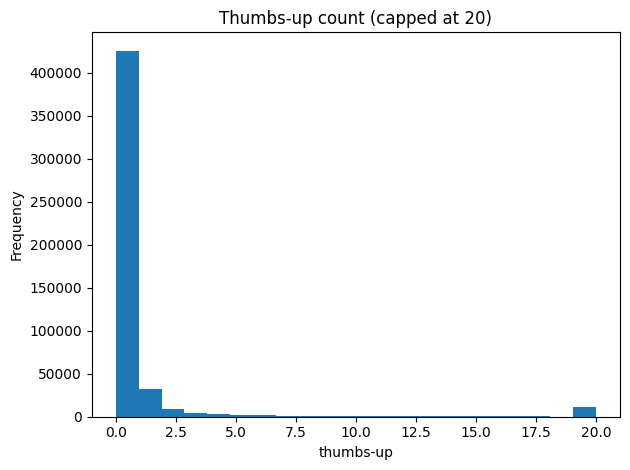

In [15]:
# Numeric summary first — expect a huge max but a median of 0
print(reviews["thumbsUpCount"].describe())

# How many reviews got ZERO thumbs-up?
zero = (reviews["thumbsUpCount"] == 0).mean() * 100
print(f"\nReviews with 0 thumbs-up: {zero:.1f}%")

# Histogram, capped so the tiny fraction of viral reviews doesn't flatten the chart
reviews["thumbsUpCount"].clip(upper=20).plot(
    kind="hist", bins=21, title="Thumbs-up count (capped at 20)"
)
plt.xlabel("thumbs-up")
plt.tight_layout()
plt.show()